In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.model_selection import train_test_split
from torch_geometric.data import Data
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.utils import add_self_loops, degree, to_dense_adj, dense_to_sparse
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

# 设置随机种子
def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    
set_seed(42)

print("Libraries imported successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Current CUDA device: {torch.cuda.current_device()}")
    print(f"GPU Name: {torch.cuda.get_device_name()}")

/home/renqi/miniconda3/envs/GNN/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries imported successfully.
PyTorch version: 2.4.1+cu124
CUDA available: True
Current CUDA device: 0
GPU Name: NVIDIA A800 80GB PCIe


# GraphMAE: Graph Masked Autoencoder for Fraud Detection

## 方法概述
GraphMAE是一种基于图自编码器的自监督学习方法，通过掩码重建任务学习图的表示。

### 核心思想：
1. **特征掩码 (Feature Masking)**: 随机掩码部分节点的特征
2. **编码器 (Encoder)**: 使用GNN对掩码后的图进行编码，得到节点嵌入
3. **解码器 (Decoder)**: 重建被掩码节点的原始特征
4. **异常检测**: 使用重建误差作为异常分数（欺诈节点难以被正确重建）

### 与原始GraphMAE的区别：
- 针对欺诈检测任务进行了优化
- 使用边级异常分数进行交易欺诈检测
- 添加了多种评估指标

In [3]:
# ============================================================================
# 1. 数据加载与预处理 (与try_paysim.ipynb一致)
# ============================================================================

file_path = r'../Dataset/Paysim/Paysim.csv'

print("="*80)
print("STEP 1: Data Loading and Preprocessing (GraphMAE)")
print("="*80)

# 数据采样配置
USE_FULL_DATASET = False  # 设置为True加载完整数据集，False使用采样
SAMPLE_SIZE = 500000  # 仅在USE_FULL_DATASET=False时生效

if USE_FULL_DATASET:
    print(f"\n⚠️ Loading FULL dataset from Paysim (this may take a while)...")
    df = pd.read_csv(file_path)
    print(f"✓ Full dataset loaded. Shape: {df.shape}")
else:
    print(f"\nLoading {SAMPLE_SIZE} transactions from Paysim dataset (sampled)...")
    df = pd.read_csv(file_path, nrows=SAMPLE_SIZE)
    print(f"✓ Sampled data loaded. Shape: {df.shape}")

# 数据探索
print(f"\n--- Data Overview ---")
print(f"Fraud ratio: {df['isFraud'].mean():.4f} ({df['isFraud'].sum()} frauds)")
print(f"Transaction types: {df['type'].unique()}")
print(f"Columns: {list(df.columns)}")

# 保存标签
y = df['isFraud'].values

# ============================================================================
# 特征工程 - 类别编码
# ============================================================================
print(f"\n--- Feature Engineering ---")
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])

# ============================================================================
# 节点映射与图构建
# ============================================================================
print(f"\n--- Graph Construction ---")

# 获取所有唯一账户
orig = df['nameOrig'].unique()
dest = df['nameDest'].unique()
all_nodes = np.union1d(orig, dest)
num_nodes = len(all_nodes)
print(f"Total unique accounts (nodes): {num_nodes}")

# 创建节点映射
node_map = {name: i for i, name in enumerate(all_nodes)}

# 映射节点ID
df['src_id'] = df['nameOrig'].map(node_map)
df['dst_id'] = df['nameDest'].map(node_map)

# 构建边索引
edge_index = torch.tensor([df['src_id'].values, df['dst_id'].values], dtype=torch.long)
print(f"✓ Edge index created. Shape: {edge_index.shape}, Total edges: {edge_index.shape[1]}")

STEP 1: Data Loading and Preprocessing (GraphMAE)

Loading 500000 transactions from Paysim dataset (sampled)...
✓ Sampled data loaded. Shape: (500000, 11)

--- Data Overview ---
Fraud ratio: 0.0005 (233 frauds)
Transaction types: ['PAYMENT' 'TRANSFER' 'CASH_OUT' 'DEBIT' 'CASH_IN']
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']

--- Feature Engineering ---

--- Graph Construction ---
Total unique accounts (nodes): 714803
✓ Edge index created. Shape: torch.Size([2, 500000]), Total edges: 500000


In [4]:
# ============================================================================
# 节点特征构建 - 双向聚合 + 统计特征 (与try_paysim.ipynb一致)
# ============================================================================
print(f"\n--- Node Feature Aggregation (Enhanced) ---")

# 基础交易特征
feat_cols = ['step', 'type_encoded', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 
             'oldbalanceDest', 'newbalanceDest']

# 标准化交易特征
scaler = StandardScaler()
edge_features_raw = df[feat_cols].values
edge_features = scaler.fit_transform(edge_features_raw)
edge_features = torch.tensor(edge_features, dtype=torch.float)

num_edge_features = edge_features.shape[1]
print(f"Edge features shape: {edge_features.shape}")

# 为了更高效，使用torch_scatter
try:
    from torch_scatter import scatter_mean, scatter_add
    print("✓ Using torch_scatter for efficient aggregation")
    
    # 初始化节点特征矩阵
    x = torch.zeros((num_nodes, num_edge_features * 2 + 2), dtype=torch.float)
    
    # 1. 聚合作为源节点(发送方)的交易特征
    x_src = scatter_mean(edge_features, edge_index[0], dim=0, dim_size=num_nodes)
    
    # 2. 聚合作为目标节点(接收方)的交易特征
    x_dst = scatter_mean(edge_features, edge_index[1], dim=0, dim_size=num_nodes)
    
    # 3. 统计特征：交易次数
    src_counts = scatter_add(torch.ones(edge_index.shape[1]), edge_index[0], dim=0, dim_size=num_nodes)
    dst_counts = scatter_add(torch.ones(edge_index.shape[1]), edge_index[1], dim=0, dim_size=num_nodes)
    
    # 组合特征
    x[:, :num_edge_features] = x_src
    x[:, num_edge_features:2*num_edge_features] = x_dst
    x[:, 2*num_edge_features] = src_counts.float()
    x[:, 2*num_edge_features+1] = dst_counts.float()
    
except ImportError:
    print("⚠️ torch_scatter not available, using slower manual aggregation")
    # 手动聚合
    temp_df = pd.DataFrame(edge_features.numpy(), columns=[f'feat_{i}' for i in range(num_edge_features)])
    temp_df['src_id'] = df['src_id'].values
    temp_df['dst_id'] = df['dst_id'].values
    
    src_agg = temp_df.groupby('src_id')[[f'feat_{i}' for i in range(num_edge_features)]].mean()
    dst_agg = temp_df.groupby('dst_id')[[f'feat_{i}' for i in range(num_edge_features)]].mean()
    
    src_counts_df = temp_df.groupby('src_id').size()
    dst_counts_df = temp_df.groupby('dst_id').size()
    
    x = torch.zeros((num_nodes, num_edge_features * 2 + 2), dtype=torch.float)
    
    for node_id in range(num_nodes):
        if node_id in src_agg.index:
            x[node_id, :num_edge_features] = torch.tensor(src_agg.loc[node_id].values, dtype=torch.float)
        if node_id in dst_agg.index:
            x[node_id, num_edge_features:2*num_edge_features] = torch.tensor(dst_agg.loc[node_id].values, dtype=torch.float)
        if node_id in src_counts_df.index:
            x[node_id, 2*num_edge_features] = src_counts_df[node_id]
        if node_id in dst_counts_df.index:
            x[node_id, 2*num_edge_features+1] = dst_counts_df[node_id]

# 处理NaN
x = torch.where(torch.isnan(x), torch.zeros_like(x), x)

print(f"✓ Node feature matrix created. Shape: {x.shape}")
print(f"  - Features per node: {x.shape[1]}")

# ============================================================================
# 图增强：添加自环
# ============================================================================
print(f"\n--- Graph Enhancement ---")

edge_index_with_loops, _ = add_self_loops(edge_index, num_nodes=num_nodes)
print(f"✓ Self-loops added. New edge count: {edge_index_with_loops.shape[1]}")

# 计算度数用于归一化
row, col = edge_index_with_loops
deg = degree(row, num_nodes, dtype=torch.float)
deg_inv_sqrt = deg.pow(-0.5)
deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
edge_weight = deg_inv_sqrt[row] * deg_inv_sqrt[col]

print(f"✓ Edge normalization computed")

# ============================================================================
# 构建 PyG Data 对象
# ============================================================================
data = Data(
    x=x, 
    edge_index=edge_index_with_loops,
    edge_weight=edge_weight,
    y=torch.tensor(y, dtype=torch.float),
    original_edge_index=edge_index,
    num_nodes=num_nodes
)

print(f"\n✓ Graph data object created")
print(f"  - Nodes: {data.num_nodes}")
print(f"  - Edges (with self-loops): {data.edge_index.shape[1]}")
print(f"  - Node features: {data.x.shape[1]}")
print(f"  - Fraudulent transactions: {data.y.sum().item()}")

print("\n" + "="*80)
print("Data preprocessing complete!")
print("="*80)


--- Node Feature Aggregation (Enhanced) ---
Edge features shape: torch.Size([500000, 7])
✓ Using torch_scatter for efficient aggregation
✓ Node feature matrix created. Shape: torch.Size([714803, 16])
  - Features per node: 16

--- Graph Enhancement ---
✓ Self-loops added. New edge count: 1214803
✓ Edge normalization computed

✓ Graph data object created
  - Nodes: 714803
  - Edges (with self-loops): 1214803
  - Node features: 16
  - Fraudulent transactions: 233.0

Data preprocessing complete!


In [5]:
# ============================================================================
# 图结构统计信息输出
# ============================================================================

print("="*80)
print("图结构统计信息 (Graph Structure Statistics)")
print("="*80)

print(f"\n📊 基本统计 (Basic Statistics):")
print(f"  ✓ 原始交易数 (Original Transactions): {len(df):,}")
print(f"  ✓ 节点数量 (Nodes/Accounts): {data.num_nodes:,}")
print(f"  ✓ 原始边数量 (Original Edges): {data.original_edge_index.shape[1]:,}")
print(f"  ✓ 添加自环后边数量 (Edges with Self-loops): {data.edge_index.shape[1]:,}")

print(f"\n📈 节点特征 (Node Features):")
print(f"  ✓ 特征维度 (Feature Dimension): {data.x.shape[1]}")
print(f"  ✓ 节点特征矩阵形状 (Node Feature Shape): {data.x.shape}")

print(f"\n👥 账户类型分析 (Account Type Analysis):")
orig_accounts = set(df['nameOrig'].unique())
dest_accounts = set(df['nameDest'].unique())
both_accounts = orig_accounts & dest_accounts
only_orig = orig_accounts - dest_accounts
only_dest = dest_accounts - orig_accounts

print(f"  ✓ 仅作为发送方的账户 (Source-only): {len(only_orig):,}")
print(f"  ✓ 仅作为接收方的账户 (Dest-only): {len(only_dest):,}")
print(f"  ✓ 既发送又接收的账户 (Both): {len(both_accounts):,}")

print(f"\n🎯 标签信息 (Label Information):")
print(f"  ✓ 总交易数 (Total Transactions): {len(data.y):,}")
print(f"  ✓ 欺诈交易数 (Fraudulent Transactions): {int(data.y.sum()):,}")
print(f"  ✓ 欺诈比例 (Fraud Ratio): {data.y.mean():.4%}")

# 按交易类型统计
print(f"\n💳 交易类型分布 (Transaction Type Distribution):")
for trans_type in df['type'].unique():
    type_count = (df['type'] == trans_type).sum()
    type_fraud = df[df['type'] == trans_type]['isFraud'].sum()
    fraud_rate = type_fraud / type_count if type_count > 0 else 0
    print(f"  ✓ {trans_type:15s}: {type_count:8,} 笔 | 欺诈: {int(type_fraud):5,} ({fraud_rate:.4%})")

print(f"\n🔗 图密度与连通性 (Graph Density & Connectivity):")
max_possible_edges = data.num_nodes * (data.num_nodes - 1)
original_density = (data.original_edge_index.shape[1] / max_possible_edges) * 100
print(f"  ✓ 图密度 (Graph Density): {original_density:.8f}%")

# 计算节点度数统计
node_in_degree = degree(data.original_edge_index[1], num_nodes=data.num_nodes).cpu().numpy()
node_out_degree = degree(data.original_edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
node_total_degree = node_in_degree + node_out_degree

print(f"\n📊 节点度数统计 (Node Degree Statistics):")
print(f"  ✓ 平均入度 (Avg In-degree): {node_in_degree.mean():.2f}")
print(f"  ✓ 平均出度 (Avg Out-degree): {node_out_degree.mean():.2f}")
print(f"  ✓ 平均总度数 (Avg Total Degree): {node_total_degree.mean():.2f}")
print(f"  ✓ 最大总度数 (Max Total Degree): {int(node_total_degree.max())}")

print("\n" + "="*80)

图结构统计信息 (Graph Structure Statistics)

📊 基本统计 (Basic Statistics):
  ✓ 原始交易数 (Original Transactions): 500,000
  ✓ 节点数量 (Nodes/Accounts): 714,803
  ✓ 原始边数量 (Original Edges): 500,000
  ✓ 添加自环后边数量 (Edges with Self-loops): 1,214,803

📈 节点特征 (Node Features):
  ✓ 特征维度 (Feature Dimension): 16
  ✓ 节点特征矩阵形状 (Node Feature Shape): torch.Size([714803, 16])

👥 账户类型分析 (Account Type Analysis):
  ✓ 仅作为发送方的账户 (Source-only): 499,947
  ✓ 仅作为接收方的账户 (Dest-only): 214,850
  ✓ 既发送又接收的账户 (Both): 6

🎯 标签信息 (Label Information):
  ✓ 总交易数 (Total Transactions): 500,000
  ✓ 欺诈交易数 (Fraudulent Transactions): 233
  ✓ 欺诈比例 (Fraud Ratio): 0.0466%

💳 交易类型分布 (Transaction Type Distribution):
  ✓ PAYMENT        :  164,032 笔 | 欺诈:     0 (0.0000%)
  ✓ TRANSFER       :   40,730 笔 | 欺诈:   112 (0.2750%)
  ✓ CASH_OUT       :  182,316 笔 | 欺诈:   121 (0.0664%)
  ✓ DEBIT          :    3,603 笔 | 欺诈:     0 (0.0000%)
  ✓ CASH_IN        :  109,319 笔 | 欺诈:     0 (0.0000%)

🔗 图密度与连通性 (Graph Density & Connectivity):
  ✓ 图密度 (Graph Density): 0.

## 2. GraphMAE 模型架构

### 架构组成：
1. **Encoder**: GNN编码器 (使用GAT或GCN)
2. **Decoder**: 轻量级MLP解码器
3. **Masking Strategy**: 随机掩码节点特征
4. **Loss**: Scaled Cosine Error (SCE) 损失函数

### 关键创新点：
- **重新掩码策略 (Re-masking)**: 防止信息泄露
- **SCE损失**: 比MSE更稳定，对异常值更鲁棒
- **非对称架构**: 轻量级解码器减少计算量

In [6]:
# ============================================================================
# 2. GraphMAE 模型架构
# ============================================================================

print("="*80)
print("STEP 2: GraphMAE Model Architecture")
print("="*80)

# ============================================================================
# GNN Encoder - 使用GAT (Graph Attention Network)
# ============================================================================
class GATEncoder(nn.Module):
    """
    GAT编码器 - 使用多头注意力机制聚合邻居信息
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, 
                 num_heads=4, dropout=0.3, concat=True):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        # 第一层
        self.convs.append(GATConv(in_channels, hidden_channels, heads=num_heads, 
                                   concat=concat, dropout=dropout))
        if concat:
            self.norms.append(nn.LayerNorm(hidden_channels * num_heads))
        else:
            self.norms.append(nn.LayerNorm(hidden_channels))
        
        # 中间层
        for _ in range(num_layers - 2):
            if concat:
                self.convs.append(GATConv(hidden_channels * num_heads, hidden_channels, 
                                          heads=num_heads, concat=concat, dropout=dropout))
                self.norms.append(nn.LayerNorm(hidden_channels * num_heads))
            else:
                self.convs.append(GATConv(hidden_channels, hidden_channels, 
                                          heads=num_heads, concat=concat, dropout=dropout))
                self.norms.append(nn.LayerNorm(hidden_channels))
        
        # 最后一层
        if num_layers > 1:
            if concat:
                self.convs.append(GATConv(hidden_channels * num_heads, out_channels, 
                                          heads=1, concat=False, dropout=dropout))
            else:
                self.convs.append(GATConv(hidden_channels, out_channels, 
                                          heads=1, concat=False, dropout=dropout))
        
        self.head_norms = nn.LayerNorm(out_channels)
        
    def forward(self, x, edge_index):
        for i in range(self.num_layers - 1):
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = F.elu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        # 最后一层
        x = self.convs[-1](x, edge_index)
        x = self.head_norms(x)
        
        return x

# ============================================================================
# GCN Encoder - 备选方案
# ============================================================================
class GCNEncoder(nn.Module):
    """
    GCN编码器 - 更轻量级的选择
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.3):
        super().__init__()
        self.num_layers = num_layers
        self.dropout = dropout
        
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()
        
        # 第一层
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.norms.append(nn.LayerNorm(hidden_channels))
        
        # 中间层
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.norms.append(nn.LayerNorm(hidden_channels))
        
        # 最后一层
        if num_layers > 1:
            self.convs.append(GCNConv(hidden_channels, out_channels))
        
        self.head_norms = nn.LayerNorm(out_channels)
        
    def forward(self, x, edge_index):
        for i in range(self.num_layers - 1):
            x = self.convs[i](x, edge_index)
            x = self.norms[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        
        x = self.convs[-1](x, edge_index)
        x = self.head_norms(x)
        
        return x

# ============================================================================
# Decoder - 轻量级MLP解码器
# ============================================================================
class MLPDecoder(nn.Module):
    """
    MLP解码器 - 重建被掩码节点的原始特征
    GraphMAE使用轻量级解码器，与重型编码器形成非对称架构
    """
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=1):
        super().__init__()
        
        if num_layers == 1:
            self.decoder = nn.Linear(in_channels, out_channels)
        else:
            layers = []
            layers.append(nn.Linear(in_channels, hidden_channels))
            layers.append(nn.PReLU())
            
            for _ in range(num_layers - 2):
                layers.append(nn.Linear(hidden_channels, hidden_channels))
                layers.append(nn.PReLU())
            
            layers.append(nn.Linear(hidden_channels, out_channels))
            self.decoder = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.decoder(x)

print("✓ Encoder and Decoder modules defined")

STEP 2: GraphMAE Model Architecture
✓ Encoder and Decoder modules defined


In [7]:
# ============================================================================
# GraphMAE 完整模型
# ============================================================================

class GraphMAE(nn.Module):
    """
    GraphMAE: Graph Masked Autoencoder
    
    核心流程：
    1. 随机掩码部分节点的特征
    2. 使用可学习的[MASK]令牌替换被掩码的特征
    3. 通过GNN编码器获取节点嵌入
    4. 使用解码器重建被掩码节点的原始特征
    5. 计算重建损失（仅在被掩码节点上）
    
    异常检测原理：
    - 正常节点特征可以从邻居信息中被很好地重建
    - 欺诈节点的行为模式异常，难以被正确重建
    - 使用重建误差作为异常分数
    """
    def __init__(self, in_channels, hidden_channels, out_channels, 
                 encoder_type='gat', num_layers=2, num_heads=4, 
                 decoder_layers=1, dropout=0.3, mask_rate=0.5, 
                 replace_rate=0.1):
        super().__init__()
        
        self.mask_rate = mask_rate
        self.replace_rate = replace_rate
        self.in_channels = in_channels
        
        # 可学习的掩码令牌
        self.mask_token = nn.Parameter(torch.zeros(1, in_channels))
        nn.init.xavier_uniform_(self.mask_token)
        
        # 编码器映射层（将输入特征映射到隐藏空间）
        self.encoder_to_decoder = nn.Linear(out_channels, out_channels, bias=False)
        
        # 选择编码器类型
        if encoder_type == 'gat':
            self.encoder = GATEncoder(in_channels, hidden_channels, out_channels, 
                                       num_layers, num_heads, dropout)
        else:
            self.encoder = GCNEncoder(in_channels, hidden_channels, out_channels, 
                                       num_layers, dropout)
        
        # 解码器
        self.decoder = MLPDecoder(out_channels, hidden_channels, in_channels, decoder_layers)
        
        # 特征投影层（用于异常检测）
        self.projection = nn.Sequential(
            nn.Linear(out_channels, out_channels),
            nn.PReLU(),
            nn.Linear(out_channels, out_channels)
        )
        
    def encoding_mask_noise(self, x, mask_rate):
        """
        对节点特征进行掩码
        
        策略：
        - mask_rate比例的节点被掩码
        - replace_rate比例的掩码节点使用随机特征替换
        - 其余掩码节点使用可学习的[MASK]令牌
        """
        num_nodes = x.shape[0]
        perm = torch.randperm(num_nodes, device=x.device)
        
        # 选择要掩码的节点数量
        num_mask_nodes = int(mask_rate * num_nodes)
        
        # 掩码节点索引和保留节点索引
        mask_nodes = perm[:num_mask_nodes]
        keep_nodes = perm[num_mask_nodes:]
        
        # 创建掩码后的特征
        out_x = x.clone()
        
        # 随机替换 vs 使用mask token
        num_replace = int(self.replace_rate * num_mask_nodes)
        perm_mask = torch.randperm(num_mask_nodes, device=x.device)
        replace_nodes = mask_nodes[perm_mask[:num_replace]]
        mask_token_nodes = mask_nodes[perm_mask[num_replace:]]
        
        # 使用随机特征替换
        if num_replace > 0:
            random_features = torch.randn_like(x[replace_nodes])
            out_x[replace_nodes] = random_features
        
        # 使用mask token替换
        if len(mask_token_nodes) > 0:
            out_x[mask_token_nodes] = self.mask_token
        
        return out_x, (mask_nodes, keep_nodes)
    
    def forward(self, x, edge_index):
        """
        前向传播 - 训练模式
        """
        # 1. 掩码节点特征
        masked_x, (mask_nodes, keep_nodes) = self.encoding_mask_noise(x, self.mask_rate)
        
        # 2. 编码
        enc_rep = self.encoder(masked_x, edge_index)
        
        # 3. 编码器到解码器的映射
        rep = self.encoder_to_decoder(enc_rep)
        
        # 4. 重新掩码（re-masking）- 防止信息泄露
        # 只重建被掩码的节点
        rep[mask_nodes] = 0
        
        # 5. 解码
        recon = self.decoder(rep)
        
        # 6. 只返回被掩码节点的重建结果和原始特征
        x_init = x[mask_nodes]
        x_rec = recon[mask_nodes]
        
        return x_rec, x_init, enc_rep
    
    def get_embeddings(self, x, edge_index):
        """
        获取节点嵌入（推理模式，不进行掩码）
        """
        self.eval()
        with torch.no_grad():
            enc_rep = self.encoder(x, edge_index)
        return enc_rep
    
    def compute_reconstruction_error(self, x, edge_index):
        """
        计算每个节点的重建误差（用于异常检测）
        
        方法：对每个节点进行单独掩码和重建，计算重建误差
        为了效率，我们使用批量方式近似计算
        """
        self.eval()
        with torch.no_grad():
            # 获取完整的编码表示
            enc_rep = self.encoder(x, edge_index)
            rep = self.encoder_to_decoder(enc_rep)
            
            # 全部解码
            recon_all = self.decoder(rep)
            
            # 计算每个节点的重建误差（余弦距离）
            x_norm = F.normalize(x, p=2, dim=1)
            recon_norm = F.normalize(recon_all, p=2, dim=1)
            
            # 余弦距离 = 1 - 余弦相似度
            cos_sim = (x_norm * recon_norm).sum(dim=1)
            recon_error = 1 - cos_sim
            
            return recon_error
    
    def compute_node_anomaly_score(self, x, edge_index, num_samples=10):
        """
        计算节点级异常分数
        使用多次采样取平均，提高稳定性
        """
        self.eval()
        scores_list = []
        
        with torch.no_grad():
            for _ in range(num_samples):
                # 随机掩码
                masked_x, (mask_nodes, _) = self.encoding_mask_noise(x, self.mask_rate)
                
                # 编码和解码
                enc_rep = self.encoder(masked_x, edge_index)
                rep = self.encoder_to_decoder(enc_rep)
                rep[mask_nodes] = 0
                recon = self.decoder(rep)
                
                # 计算掩码节点的重建误差
                x_norm = F.normalize(x, p=2, dim=1)
                recon_norm = F.normalize(recon, p=2, dim=1)
                
                cos_sim = (x_norm * recon_norm).sum(dim=1)
                error = 1 - cos_sim
                
                # 创建完整的分数向量
                scores = torch.zeros(x.shape[0], device=x.device)
                scores[mask_nodes] = error[mask_nodes]
                scores_list.append(scores)
            
            # 取平均
            avg_scores = torch.stack(scores_list).mean(dim=0)
            
        return avg_scores

# ============================================================================
# SCE Loss (Scaled Cosine Error)
# ============================================================================
class SCELoss(nn.Module):
    """
    Scaled Cosine Error Loss
    
    GraphMAE使用SCE而非MSE，因为：
    1. 对异常值更鲁棒
    2. 避免了特征尺度的影响
    3. 训练更稳定
    """
    def __init__(self, alpha=2):
        super().__init__()
        self.alpha = alpha
        
    def forward(self, pred, target):
        # 归一化
        pred = F.normalize(pred, p=2, dim=-1)
        target = F.normalize(target, p=2, dim=-1)
        
        # 余弦相似度
        cos_sim = (pred * target).sum(dim=-1)
        
        # SCE: (1 - cos_sim)^alpha
        loss = (1 - cos_sim).pow(self.alpha)
        
        return loss.mean()

print("✓ GraphMAE model defined")
print("✓ SCE Loss function defined")

✓ GraphMAE model defined
✓ SCE Loss function defined


In [8]:
# ============================================================================
# 3. 训练与评估
# ============================================================================

print("="*80)
print("STEP 3: Model Training & Evaluation")
print("="*80)

# ============================================================================
# 超参数配置
# ============================================================================
config = {
    'hidden_channels': 128,      # 隐藏层维度
    'out_channels': 64,          # 嵌入维度
    'encoder_type': 'gat',       # 编码器类型: 'gat' 或 'gcn'
    'num_layers': 3,             # GNN层数
    'num_heads': 8,              # GAT注意力头数
    'decoder_layers': 1,         # 解码器层数
    'dropout': 0.3,              # Dropout率
    'mask_rate': 0.5,            # 掩码比例
    'replace_rate': 0.1,         # 随机替换比例
    'lr': 0.001,                 # 学习率
    'weight_decay': 1e-5,        # L2正则化
    'epochs': 500,               # 训练轮数
    'patience': 15,              # 早停耐心值
    'alpha': 2,                  # SCE损失的alpha参数
}

print("\n--- Hyperparameters ---")
for key, value in config.items():
    print(f"  {key}: {value}")

# ============================================================================
# 设备配置
# ============================================================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Using device: {device}")

# 移动数据到设备
data = data.to(device)

# ============================================================================
# 创建训练/验证分割
# ============================================================================
print("\n--- Creating Train/Val Split ---")

num_edges = data.original_edge_index.shape[1]
train_idx, val_idx = train_test_split(
    np.arange(num_edges), 
    test_size=0.2, 
    random_state=42,
    stratify=data.y.cpu().numpy()
)

print(f"✓ Train edges: {len(train_idx)}")
print(f"✓ Val edges: {len(val_idx)}")
print(f"  - Train fraud ratio: {data.y[train_idx].mean():.4f}")
print(f"  - Val fraud ratio: {data.y[val_idx].mean():.4f}")

# ============================================================================
# 初始化模型
# ============================================================================
print("\n--- Initializing Model ---")

in_channels = data.x.shape[1]
model = GraphMAE(
    in_channels=in_channels,
    hidden_channels=config['hidden_channels'],
    out_channels=config['out_channels'],
    encoder_type=config['encoder_type'],
    num_layers=config['num_layers'],
    num_heads=config['num_heads'],
    decoder_layers=config['decoder_layers'],
    dropout=config['dropout'],
    mask_rate=config['mask_rate'],
    replace_rate=config['replace_rate']
).to(device)

# 优化器
optimizer = torch.optim.Adam(
    model.parameters(), 
    lr=config['lr'],
    weight_decay=config['weight_decay']
)

# 学习率调度器
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=10, verbose=True
)

# 损失函数
criterion = SCELoss(alpha=config['alpha'])

print(f"✓ Model initialized")
print(f"  - Total parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"  - Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

STEP 3: Model Training & Evaluation

--- Hyperparameters ---
  hidden_channels: 128
  out_channels: 64
  encoder_type: gat
  num_layers: 3
  num_heads: 8
  decoder_layers: 1
  dropout: 0.3
  mask_rate: 0.5
  replace_rate: 0.1
  lr: 0.001
  weight_decay: 1e-05
  epochs: 500
  patience: 15
  alpha: 2

✓ Using device: cuda

--- Creating Train/Val Split ---
✓ Train edges: 400000
✓ Val edges: 100000
  - Train fraud ratio: 0.0005
  - Val fraud ratio: 0.0005

--- Initializing Model ---
✓ Model initialized
  - Total parameters: 1,154,529
  - Trainable parameters: 1,154,529


In [9]:
# ============================================================================
# 训练循环
# ============================================================================
print("\n" + "="*80)
print("Training Start")
print("="*80)

best_val_loss = float('inf')
patience_counter = 0
train_losses = []
val_aucs = []

for epoch in range(config['epochs']):
    # ========== 训练阶段 ==========
    model.train()
    optimizer.zero_grad()
    
    # 前向传播
    x_rec, x_init, _ = model(data.x, data.edge_index)
    
    # 计算损失（SCE Loss）
    loss = criterion(x_rec, x_init)
    
    # 反向传播
    loss.backward()
    
    # 梯度裁剪
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
    
    optimizer.step()
    
    train_losses.append(loss.item())
    
    # ========== 验证阶段 ==========
    if (epoch + 1) % 5 == 0:
        model.eval()
        with torch.no_grad():
            # 计算重建误差作为节点异常分数
            node_scores = model.compute_reconstruction_error(
                data.x, data.edge_index
            ).cpu().numpy()
            
            # 映射到验证集的边
            val_edge_index = data.original_edge_index[:, val_idx]
            val_src = val_edge_index[0].cpu().numpy()
            val_dst = val_edge_index[1].cpu().numpy()
            
            # 计算边级异常分数（使用max策略）
            val_scores = np.maximum(node_scores[val_src], node_scores[val_dst])
            val_labels = data.y[val_idx].cpu().numpy()
            
            # 计算AUC
            val_auc = roc_auc_score(val_labels, val_scores)
            val_aucs.append(val_auc)
            
            val_loss = loss.item()
            
            print(f"Epoch {epoch+1:3d}/{config['epochs']} | "
                  f"Train Loss: {loss.item():.4f} | "
                  f"Val AUC: {val_auc:.4f} | "
                  f"LR: {optimizer.param_groups[0]['lr']:.6f}")
            
            # 早停检查
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                patience_counter = 0
                best_model_state = model.state_dict()
            else:
                patience_counter += 1
                
            if patience_counter >= config['patience']:
                print(f"\n⚠️ Early stopping triggered at epoch {epoch+1}")
                break
            
            scheduler.step(val_loss)
    
    elif (epoch + 1) % 1 == 0:
        print(f"Epoch {epoch+1:3d}/{config['epochs']} | Train Loss: {loss.item():.4f}")

# 加载最佳模型
print(f"\n✓ Training complete!")
print(f"✓ Loading best model...")
model.load_state_dict(best_model_state)


Training Start
Epoch   1/500 | Train Loss: 1.2686
Epoch   2/500 | Train Loss: 1.2607
Epoch   3/500 | Train Loss: 1.2526
Epoch   4/500 | Train Loss: 1.2459
Epoch   5/500 | Train Loss: 1.2375 | Val AUC: 0.6768 | LR: 0.001000
Epoch   6/500 | Train Loss: 1.2302
Epoch   7/500 | Train Loss: 1.2217
Epoch   8/500 | Train Loss: 1.2154
Epoch   9/500 | Train Loss: 1.2072
Epoch  10/500 | Train Loss: 1.2002 | Val AUC: 0.6422 | LR: 0.001000
Epoch  11/500 | Train Loss: 1.1927
Epoch  12/500 | Train Loss: 1.1851
Epoch  13/500 | Train Loss: 1.1779
Epoch  14/500 | Train Loss: 1.1710
Epoch  15/500 | Train Loss: 1.1628 | Val AUC: 0.6223 | LR: 0.001000
Epoch  16/500 | Train Loss: 1.1566
Epoch  17/500 | Train Loss: 1.1490
Epoch  18/500 | Train Loss: 1.1416
Epoch  19/500 | Train Loss: 1.1335
Epoch  20/500 | Train Loss: 1.1278 | Val AUC: 0.6059 | LR: 0.001000
Epoch  21/500 | Train Loss: 1.1210
Epoch  22/500 | Train Loss: 1.1133
Epoch  23/500 | Train Loss: 1.1078
Epoch  24/500 | Train Loss: 1.1000
Epoch  25/50

<All keys matched successfully>

In [10]:
# ============================================================================
# 4. 最终评估
# ============================================================================
print("\n" + "="*80)
print("STEP 4: Final Evaluation")
print("="*80)

model.eval()
with torch.no_grad():
    # 获取节点嵌入
    node_embeddings = model.get_embeddings(data.x, data.edge_index).cpu().numpy()
    
    # 计算节点异常分数（重建误差）
    node_scores = model.compute_reconstruction_error(
        data.x, data.edge_index
    ).cpu().numpy()
    
    print(f"✓ Node anomaly scores computed. Shape: {node_scores.shape}")

# ============================================================================
# 边级异常检测 - 多种策略
# ============================================================================
print("\n--- Computing Edge-Level Anomaly Scores ---")

original_edge_index = data.original_edge_index.cpu().numpy()
src_indices = original_edge_index[0]
dst_indices = original_edge_index[1]

# 策略1: Max - 取两端节点分数的最大值
edge_scores_max = np.maximum(node_scores[src_indices], node_scores[dst_indices])

# 策略2: Mean - 取两端节点分数的平均值
edge_scores_mean = (node_scores[src_indices] + node_scores[dst_indices]) / 2

# 策略3: Edge Embedding - 基于边嵌入的差异
edge_emb_src = node_embeddings[src_indices]
edge_emb_dst = node_embeddings[dst_indices]

# 边嵌入 = 源节点嵌入 + 目标节点嵌入
edge_emb = edge_emb_src + edge_emb_dst
edge_emb_norm = edge_emb / (np.linalg.norm(edge_emb, axis=1, keepdims=True) + 1e-8)

# 策略4: 节点嵌入差异
edge_diff = np.abs(edge_emb_src - edge_emb_dst)
edge_scores_diff = np.linalg.norm(edge_diff, axis=1)

# ============================================================================
# 性能评估
# ============================================================================
y_true = data.y.cpu().numpy()

print("\n" + "="*80)
print("Performance Metrics")
print("="*80)

strategies = {
    'Max (两端节点最大重建误差)': edge_scores_max,
    'Mean (两端节点平均重建误差)': edge_scores_mean,
    'Embedding Diff (嵌入差异)': edge_scores_diff,
}

best_auc = 0
best_strategy = ""
best_scores = None

for strategy_name, scores in strategies.items():
    auc = roc_auc_score(y_true, scores)
    ap = average_precision_score(y_true, scores)
    
    print(f"\n--- {strategy_name} ---")
    print(f"  AUC-ROC: {auc:.4f}")
    print(f"  Average Precision (AP): {ap:.4f}")
    
    if auc > best_auc:
        best_auc = auc
        best_strategy = strategy_name
        best_scores = scores

print(f"\n✓ Best strategy: {best_strategy} (AUC = {best_auc:.4f})")


STEP 4: Final Evaluation
✓ Node anomaly scores computed. Shape: (714803,)

--- Computing Edge-Level Anomaly Scores ---

Performance Metrics

--- Max (两端节点最大重建误差) ---
  AUC-ROC: 0.7333
  Average Precision (AP): 0.0017

--- Mean (两端节点平均重建误差) ---
  AUC-ROC: 0.7111
  Average Precision (AP): 0.0020

--- Embedding Diff (嵌入差异) ---
  AUC-ROC: 0.7730
  Average Precision (AP): 0.0203

✓ Best strategy: Embedding Diff (嵌入差异) (AUC = 0.7730)



STEP 5: Visualizations


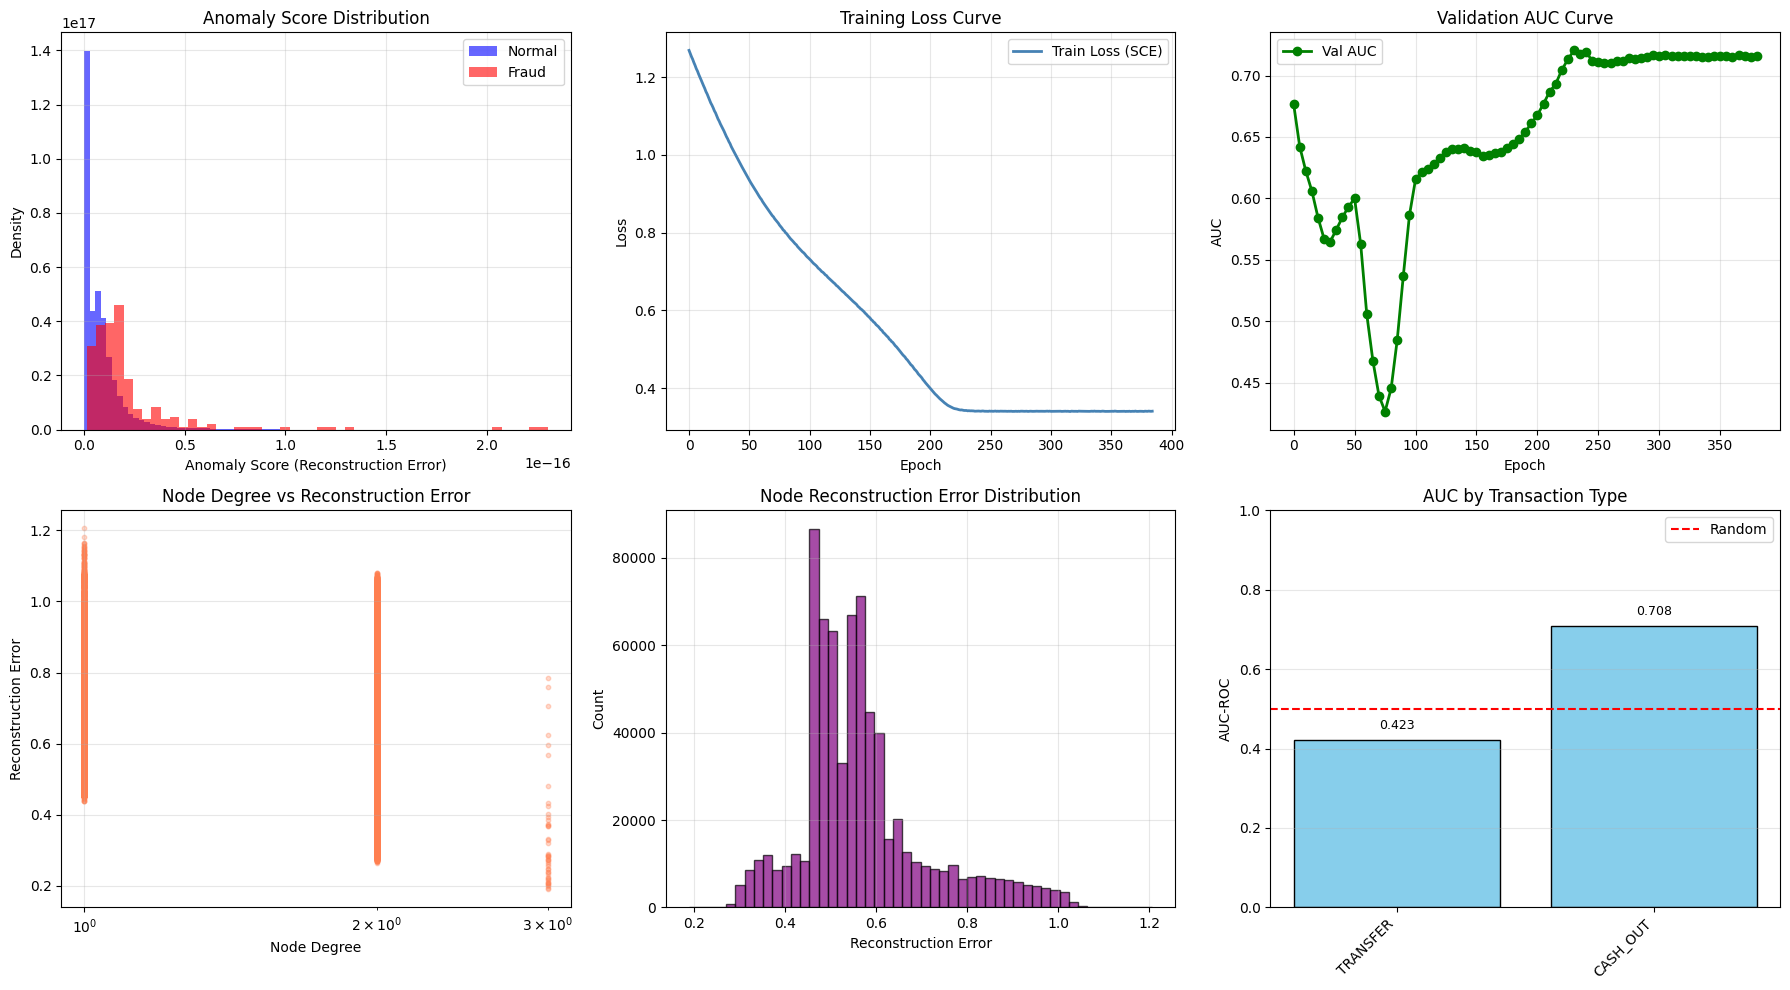


✓ Visualization complete!


In [11]:
# ============================================================================
# 5. 可视化
# ============================================================================
print("\n" + "="*80)
print("STEP 5: Visualizations")
print("="*80)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 1. 异常分数分布
ax = axes[0, 0]
ax.hist(best_scores[y_true==0], bins=50, alpha=0.6, label='Normal', density=True, color='blue')
ax.hist(best_scores[y_true==1], bins=50, alpha=0.6, label='Fraud', density=True, color='red')
ax.set_xlabel('Anomaly Score (Reconstruction Error)')
ax.set_ylabel('Density')
ax.set_title('Anomaly Score Distribution')
ax.legend()
ax.grid(True, alpha=0.3)

# 2. 训练损失曲线
ax = axes[0, 1]
ax.plot(train_losses, label='Train Loss (SCE)', linewidth=2, color='steelblue')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training Loss Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# 3. 验证AUC曲线
ax = axes[0, 2]
epochs_val = [i*5 for i in range(len(val_aucs))]
ax.plot(epochs_val, val_aucs, label='Val AUC', linewidth=2, color='green', marker='o')
ax.set_xlabel('Epoch')
ax.set_ylabel('AUC')
ax.set_title('Validation AUC Curve')
ax.legend()
ax.grid(True, alpha=0.3)

# 4. 节点度数 vs 重建误差
ax = axes[1, 0]
node_degrees = degree(data.edge_index[0], num_nodes=data.num_nodes).cpu().numpy()
ax.scatter(node_degrees, node_scores, alpha=0.3, s=10, c='coral')
ax.set_xlabel('Node Degree')
ax.set_ylabel('Reconstruction Error')
ax.set_title('Node Degree vs Reconstruction Error')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)

# 5. 节点重建误差分布
ax = axes[1, 1]
ax.hist(node_scores, bins=50, alpha=0.7, color='purple', edgecolor='black')
ax.set_xlabel('Reconstruction Error')
ax.set_ylabel('Count')
ax.set_title('Node Reconstruction Error Distribution')
ax.grid(True, alpha=0.3)

# 6. 按交易类型的AUC
ax = axes[1, 2]
type_aucs = []
type_names = []
for trans_type in df['type'].unique():
    type_mask = df['type'].values == trans_type
    if y_true[type_mask].sum() > 0 and (y_true[type_mask] == 0).sum() > 0:
        type_auc = roc_auc_score(y_true[type_mask], best_scores[type_mask])
        type_aucs.append(type_auc)
        type_names.append(trans_type)

bars = ax.bar(range(len(type_names)), type_aucs, color='skyblue', edgecolor='black')
ax.set_xticks(range(len(type_names)))
ax.set_xticklabels(type_names, rotation=45, ha='right')
ax.set_ylabel('AUC-ROC')
ax.set_title('AUC by Transaction Type')
ax.set_ylim(0, 1)
ax.axhline(y=0.5, color='r', linestyle='--', label='Random')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 为每个bar添加数值标签
for bar, auc in zip(bars, type_aucs):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
            f'{auc:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Visualization complete!")

In [12]:
# ============================================================================
# 6. 详细分析与诊断
# ============================================================================

print("="*80)
print("STEP 6: Detailed Analysis & Diagnostics")
print("="*80)

# ============================================================================
# 异常案例分析
# ============================================================================
print("\n--- Top Anomalous Transactions ---")

top_k = 20
top_anomaly_indices = np.argsort(best_scores)[-top_k:][::-1]

print(f"\nTop {top_k} most anomalous transactions (by reconstruction error):")
for i, idx in enumerate(top_anomaly_indices, 1):
    is_fraud = "✓ FRAUD" if y_true[idx] == 1 else "✗ Normal"
    print(f"  {i}. Transaction {idx} | Score: {best_scores[idx]:.4f} | {is_fraud}")

# 统计Top-K中的准确率
top_k_precision = y_true[top_anomaly_indices].mean()
print(f"\n✓ Precision@{top_k}: {top_k_precision:.2%}")

# 计算更多的Precision@K
print("\n--- Precision@K Analysis ---")
k_values = [10, 20, 50, 100, 200, 500, 1000]
for k in k_values:
    if k <= len(y_true):
        top_k_idx = np.argsort(best_scores)[-k:][::-1]
        prec_k = y_true[top_k_idx].mean()
        print(f"  Precision@{k}: {prec_k:.4f}")

# ============================================================================
# 节点异常分析
# ============================================================================
print("\n--- Node-Level Analysis ---")

top_nodes_k = 10
top_anomaly_nodes = np.argsort(node_scores)[-top_nodes_k:][::-1]

print(f"\nTop {top_nodes_k} most anomalous accounts (highest reconstruction error):")
for i, node_id in enumerate(top_anomaly_nodes, 1):
    print(f"  {i}. Node {node_id} | "
          f"Recon Error: {node_scores[node_id]:.4f} | "
          f"Degree: {node_degrees[node_id]:.0f}")

# ============================================================================
# 与基线方法比较
# ============================================================================
print("\n--- Baseline Comparison ---")

# 基线1：仅使用节点度数作为异常分数
degree_scores = node_degrees
edge_degree_scores = np.maximum(degree_scores[src_indices], degree_scores[dst_indices])
edge_degree_scores = (edge_degree_scores - edge_degree_scores.min()) / (edge_degree_scores.max() - edge_degree_scores.min() + 1e-8)

auc_degree = roc_auc_score(y_true, edge_degree_scores)
print(f"  Baseline (Degree-based): AUC = {auc_degree:.4f}")

# 基线2：仅使用交易金额
amount_scores = df['amount'].values
amount_scores = (amount_scores - amount_scores.min()) / (amount_scores.max() - amount_scores.min() + 1e-8)

auc_amount = roc_auc_score(y_true, amount_scores)
print(f"  Baseline (Amount-based): AUC = {auc_amount:.4f}")

# 我们的方法
print(f"  GraphMAE (Best Strategy): AUC = {best_auc:.4f}")

print(f"\n✓ Improvement over degree baseline: {(best_auc - auc_degree)*100:.2f}%")
print(f"✓ Improvement over amount baseline: {(best_auc - auc_amount)*100:.2f}%")

STEP 6: Detailed Analysis & Diagnostics

--- Top Anomalous Transactions ---

Top 20 most anomalous transactions (by reconstruction error):
  1. Transaction 4440 | Score: 0.0000 | ✓ FRAUD
  2. Transaction 4441 | Score: 0.0000 | ✓ FRAUD
  3. Transaction 481251 | Score: 0.0000 | ✓ FRAUD
  4. Transaction 84416 | Score: 0.0000 | ✗ Normal
  5. Transaction 217321 | Score: 0.0000 | ✓ FRAUD
  6. Transaction 66040 | Score: 0.0000 | ✗ Normal
  7. Transaction 100307 | Score: 0.0000 | ✗ Normal
  8. Transaction 100301 | Score: 0.0000 | ✗ Normal
  9. Transaction 100304 | Score: 0.0000 | ✗ Normal
  10. Transaction 100297 | Score: 0.0000 | ✗ Normal
  11. Transaction 100298 | Score: 0.0000 | ✗ Normal
  12. Transaction 100302 | Score: 0.0000 | ✗ Normal
  13. Transaction 100294 | Score: 0.0000 | ✗ Normal
  14. Transaction 100306 | Score: 0.0000 | ✗ Normal
  15. Transaction 100296 | Score: 0.0000 | ✗ Normal
  16. Transaction 100303 | Score: 0.0000 | ✗ Normal
  17. Transaction 100299 | Score: 0.0000 | ✗ Nor

  Baseline (Amount-based): AUC = 0.6033
  GraphMAE (Best Strategy): AUC = 0.7730

✓ Improvement over degree baseline: 27.31%
✓ Improvement over amount baseline: 16.98%


In [13]:
# ============================================================================
# 7. 嵌入可视化 (t-SNE)
# ============================================================================
print("\n--- Embedding Visualization (t-SNE) ---")

try:
    from sklearn.manifold import TSNE
    
    # 采样部分节点进行可视化
    sample_size = min(3000, data.num_nodes)
    sample_indices = np.random.choice(data.num_nodes, sample_size, replace=False)
    
    # 获取采样节点的嵌入
    emb_sample = node_embeddings[sample_indices]
    scores_sample = node_scores[sample_indices]
    
    print(f"✓ Performing t-SNE on {sample_size} nodes...")
    
    # t-SNE降维
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    emb_2d = tsne.fit_transform(emb_sample)
    
    # 可视化
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 按重建误差着色
    ax = axes[0]
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], 
                        c=scores_sample, cmap='coolwarm', 
                        alpha=0.6, s=15)
    ax.set_title('Node Embeddings (colored by Reconstruction Error)')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    plt.colorbar(scatter, ax=ax, label='Reconstruction Error')
    
    # 按度数着色
    ax = axes[1]
    degrees_sample = node_degrees[sample_indices]
    scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], 
                        c=np.log1p(degrees_sample), cmap='viridis', 
                        alpha=0.6, s=15)
    ax.set_title('Node Embeddings (colored by log(Degree+1))')
    ax.set_xlabel('t-SNE Dimension 1')
    ax.set_ylabel('t-SNE Dimension 2')
    plt.colorbar(scatter, ax=ax, label='log(Degree+1)')
    
    plt.tight_layout()
    plt.show()
    
    print("✓ t-SNE visualization complete")
    
except ImportError:
    print("⚠️ scikit-learn not available for t-SNE visualization")


--- Embedding Visualization (t-SNE) ---
✓ Performing t-SNE on 3000 nodes...


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
# ============================================================================
# 8. 保存结果与总结
# ============================================================================

print("\n" + "="*80)
print("STEP 8: Save Results & Summary")
print("="*80)

# 保存结果
results = {
    'node_scores': node_scores,
    'node_embeddings': node_embeddings,
    'edge_scores_max': edge_scores_max,
    'edge_scores_mean': edge_scores_mean,
    'edge_scores_diff': edge_scores_diff,
    'config': config,
    'metrics': {
        'auc_max': roc_auc_score(y_true, edge_scores_max),
        'auc_mean': roc_auc_score(y_true, edge_scores_mean),
        'auc_diff': roc_auc_score(y_true, edge_scores_diff),
        'ap_best': average_precision_score(y_true, best_scores),
        'best_strategy': best_strategy,
        'best_auc': best_auc
    },
    'training': {
        'final_loss': train_losses[-1],
        'best_val_auc': max(val_aucs) if val_aucs else 0,
        'epochs_trained': len(train_losses)
    }
}

# 保存模型（可选）
# torch.save(model.state_dict(), 'graphmae_paysim_model.pt')
# torch.save(results, 'graphmae_paysim_results.pt')
# print("✓ Model and results saved")

# ============================================================================
# 最终总结
# ============================================================================
print("\n" + "="*80)
print("Summary - GraphMAE Fraud Detection")
print("="*80)

print(f"\n📊 数据集统计:")
print(f"  ✓ 节点数 (账户): {data.num_nodes:,}")
print(f"  ✓ 边数 (交易): {data.original_edge_index.shape[1]:,}")
print(f"  ✓ 欺诈交易数: {int(data.y.sum()):,}")
print(f"  ✓ 欺诈比例: {data.y.mean():.4%}")

print(f"\n🔧 模型配置:")
print(f"  ✓ 编码器类型: {config['encoder_type'].upper()}")
print(f"  ✓ 隐藏层维度: {config['hidden_channels']}")
print(f"  ✓ 嵌入维度: {config['out_channels']}")
print(f"  ✓ 掩码比例: {config['mask_rate']}")
print(f"  ✓ GNN层数: {config['num_layers']}")

print(f"\n📈 训练结果:")
print(f"  ✓ 训练轮数: {len(train_losses)}")
print(f"  ✓ 最终损失: {train_losses[-1]:.4f}")
print(f"  ✓ 最佳验证AUC: {max(val_aucs) if val_aucs else 0:.4f}")

print(f"\n🎯 检测性能:")
print(f"  ✓ 最佳策略: {best_strategy}")
print(f"  ✓ AUC-ROC: {best_auc:.4f}")
print(f"  ✓ Average Precision: {average_precision_score(y_true, best_scores):.4f}")
print(f"  ✓ Precision@100: {y_true[np.argsort(best_scores)[-100:][::-1]].mean():.4f}")

print(f"\n📊 对比基线:")
print(f"  ✓ Degree Baseline AUC: {auc_degree:.4f}")
print(f"  ✓ Amount Baseline AUC: {auc_amount:.4f}")
print(f"  ✓ GraphMAE 提升: +{(best_auc - max(auc_degree, auc_amount))*100:.2f}%")

print("\n" + "="*80)
print("GraphMAE Fraud Detection Complete!")
print("="*80)

## 📝 GraphMAE 方法说明

### 核心原理
GraphMAE通过**掩码自编码**学习图的表示：
1. 随机掩码部分节点的特征
2. 使用GNN编码器学习图结构信息
3. 解码器尝试重建被掩码的原始特征
4. **正常节点**的特征可以从邻居信息中被准确重建
5. **异常节点**（欺诈）的行为模式异常，难以被正确重建

### 异常检测逻辑
- 重建误差高的节点更可能是异常
- 欺诈账户的交易模式与正常账户不同
- 图结构无法很好地"解释"欺诈节点的特征

### 与对比学习方法的区别
| 方面 | GraphMAE | Contrastive Learning |
|------|----------|---------------------|
| 预训练任务 | 特征重建 | 视图对比 |
| 异常分数 | 重建误差 | 视图不一致性 |
| 负样本 | 不需要 | 需要采样 |
| 计算复杂度 | 较低 | 较高 |

### 参考文献
- Hou, Z., et al. "GraphMAE: Self-supervised masked graph autoencoders." KDD 2022.